# Algorithm Comparison Metrics
This notebook will run the algorithms and compare the evaluation metrics across them.

In [1]:
%load_ext autoreload
%autoreload 2

In [17]:
import pickle

def extract_results(path, greedy: bool = False):
    full_path = f"outputs/{path}.pkl"
    with open(full_path, "rb") as f:
        results = pickle.load(f)
        
    if greedy:
        return results['solutions'], results['timings'], results['population_creation_seed']
    else:
        return results['solutions'], results['evolution_stats'], results['timings'], results['population_creation_seed']

In [20]:
solution_grid, stats_grid, time_grid, seeds_grid = extract_results('grid_city_20_experiments_analysis')
# solution_moderate, stats_moderate, time_moderate, seeds_moderate = extract_results('moderate_city_20_experiments_analysis')
solution_bottleneck, stats_bottleneck, time_bottleneck, seeds_bottleneck = extract_results('grid_city_20_experiments_analysis')

### Greedy

In [12]:
from utils.notebook import greedy_function
from utils.environment import Environment


for city_name in ['grid_city', 'bottleneck_city', 'moderate_city']:
    city = Environment(city_name=city_name)
    n_experiments = 20
    num_agents = 20
    params = {"congestion": True, "walking": False, "fitness": "max"}

    solutions, timings, seeds = greedy_function(
        city, n_experiments, num_agents, params
    )
    
    path = f'outputs/greedy_{city_name}_{n_experiments}.pkl'
    with open(path, "wb") as f:
        results = {
            # results
            'solutions': solutions, 'timings': timings,
            # metadata
            'num_agents': num_agents, 'n_experiments': n_experiments,
            'population_creation_seed': seeds
        }
        pickle.dump(results, f)

100%|██████████| 20/20 [00:10<00:00,  1.91it/s]


In [21]:
solution_grid_greedy, time_grid_greedy, seeds_grid_greedy = extract_results('greedy_grid_city_20', greedy=True)
# solution_moderate_greedy, time_moderate_greedy, seeds_moderate_greedy = extract_results('greedy_moderate_city_20', greedy=True)
solution_bottleneck_greedy, time_bottleneck_greedy, seeds_bottleneck_greedy = extract_results('greedy_bottleneck_city_20', greedy=True)

In [22]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

def compare_greedy_vs_ga(greedy_solutions, ga_solutions, city_name):
    """
    greedy_solutions: list of chromosomes from greedy experiments
    ga_solutions:     list of chromosomes from GA experiments
    """
    greedy_scores = np.array([s.fitness for s in greedy_solutions])
    ga_scores     = np.array([s.fitness for s in ga_solutions])

    # ── Core metrics ─────────────────────────────────────────────────────────
    improvement   = ((greedy_scores - ga_scores) / greedy_scores) * 100
    ga_wins       = sum(1 for g, ga in zip(greedy_scores, ga_scores) if ga < g)
    t_stat, p_val = stats.ttest_rel(greedy_scores, ga_scores)

    print(f"\n{'='*50}")
    print(f" {city_name}")
    print(f"{'='*50}")
    print(f"{'Metric':<30} {'Greedy':>10} {'GA':>10}")
    print(f"{'-'*50}")
    print(f"{'Mean'::<30} {np.mean(greedy_scores):>10.2f} {np.mean(ga_scores):>10.2f}")
    print(f"{'Std'::<30} {np.std(greedy_scores):>10.2f} {np.std(ga_scores):>10.2f}")
    print(f"{'Best'::<30} {min(greedy_scores):>10.2f} {min(ga_scores):>10.2f}")
    print(f"{'Worst'::<30} {max(greedy_scores):>10.2f} {max(ga_scores):>10.2f}")
    print(f"{'-'*50}")
    print(f"{'Mean Improvement %':<30} {np.mean(improvement):>10.2f}%")
    print(f"{'GA Win Rate':<30} {ga_wins:>9}/{len(ga_scores)}")
    print(f"{'p-value':<30} {p_val:>10.4f} {'✅' if p_val < 0.05 else '⚠️'}")

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot 1 — Box plot
    ax = axes[0]
    ax.boxplot([greedy_scores, ga_scores],
               labels=["Greedy", "GA"],
               patch_artist=True,
               boxprops=dict(facecolor="#5fb8d6", alpha=0.7),
               medianprops=dict(color="#2c3e50", linewidth=2))
    ax.set_title("Score Distribution", fontsize=12, fontweight="bold")
    ax.set_ylabel("Fitness Score")
    ax.spines[["top", "right"]].set_visible(False)

    # Plot 2 — Per experiment comparison
    ax = axes[1]
    experiments = range(len(greedy_scores))
    ax.plot(experiments, greedy_scores, color="#da5f70", linewidth=1.5,
            marker="o", markersize=3, label="Greedy")
    ax.plot(experiments, ga_scores, color="#6bbc8d", linewidth=1.5,
            marker="o", markersize=3, label="GA")
    ax.fill_between(experiments, greedy_scores, ga_scores,
                    where=(ga_scores < greedy_scores),
                    color="#6bbc8d", alpha=0.2, label="GA wins")
    ax.fill_between(experiments, greedy_scores, ga_scores,
                    where=(ga_scores >= greedy_scores),
                    color="#da5f70", alpha=0.2, label="Greedy wins")
    ax.set_title("Per Experiment Comparison", fontsize=12, fontweight="bold")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Fitness Score")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # Plot 3 — Improvement % per experiment
    ax = axes[2]
    colours = ["#6bbc8d" if i > 0 else "#da5f70" for i in improvement]
    ax.bar(experiments, improvement, color=colours, alpha=0.8)
    ax.axhline(0, color="#2c3e50", linewidth=1.5, linestyle="--")
    ax.axhline(np.mean(improvement), color="#e8a838", linewidth=2,
               linestyle="--", label=f"Mean: {np.mean(improvement):.1f}%")
    ax.set_title("Improvement % Per Experiment", fontsize=12, fontweight="bold")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Improvement %")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(f"{city_name} — Greedy vs GA", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return {
        "city":            city_name,
        "greedy_mean":     np.mean(greedy_scores),
        "greedy_std":      np.std(greedy_scores),
        "ga_mean":         np.mean(ga_scores),
        "ga_std":          np.std(ga_scores),
        "improvement_pct": np.mean(improvement),
        "ga_win_rate":     ga_wins / len(ga_scores),
        "p_value":         p_val,
    }


 Grid City
Metric                             Greedy         GA
--------------------------------------------------
Mean::::::::::::::::::::::::::      15.65      12.55
Std:::::::::::::::::::::::::::       5.04       1.12
Best::::::::::::::::::::::::::       9.00      11.00
Worst:::::::::::::::::::::::::      29.00      15.00
--------------------------------------------------
Mean Improvement %                  13.30%
GA Win Rate                           16/20
p-value                            0.0104 ✅


/var/folders/lz/6hyt90hs5rj1smnclbp276hr0000gn/T/ipykernel_74245/2091795598.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([greedy_scores, ga_scores],


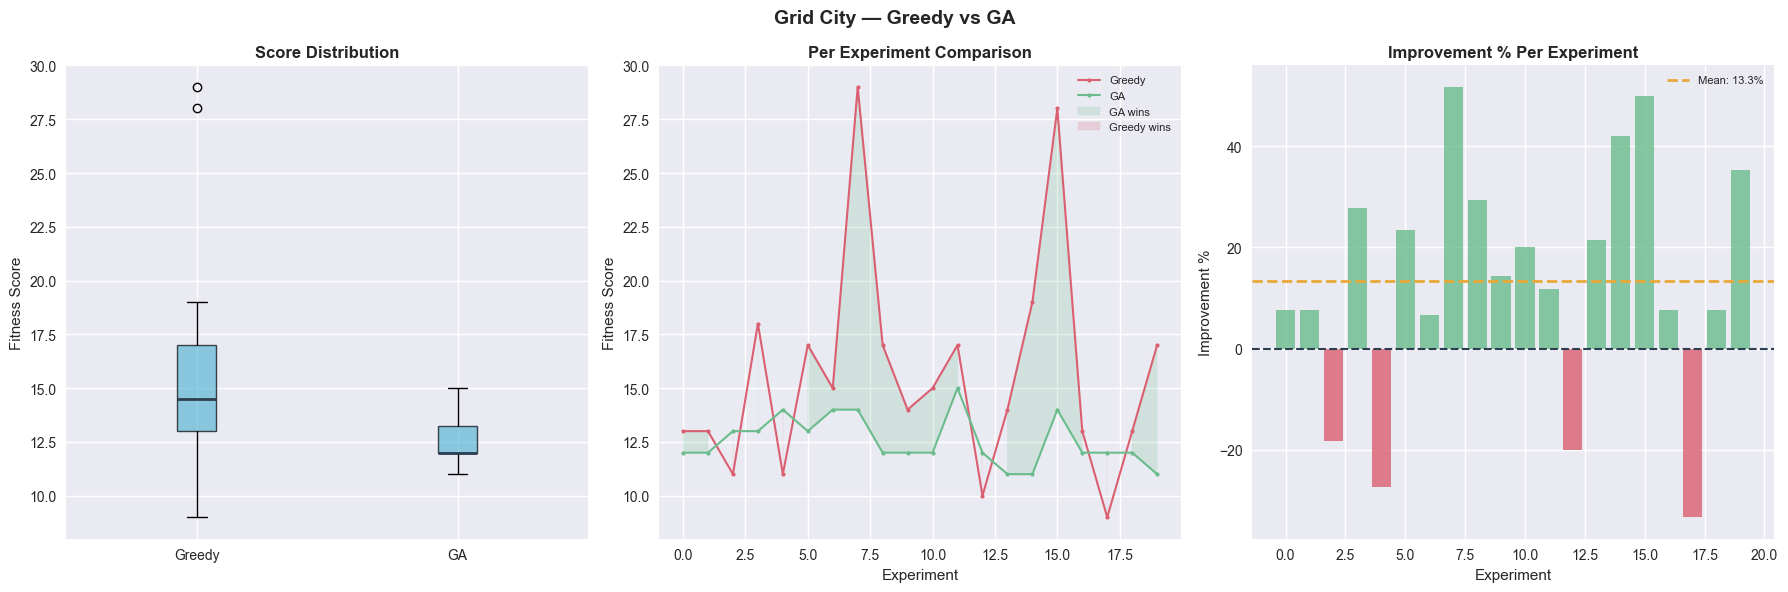


 Bottleneck City
Metric                             Greedy         GA
--------------------------------------------------
Mean::::::::::::::::::::::::::      55.10      12.55
Std:::::::::::::::::::::::::::      13.21       1.12
Best::::::::::::::::::::::::::      40.00      11.00
Worst:::::::::::::::::::::::::      81.00      15.00
--------------------------------------------------
Mean Improvement %                  75.81%
GA Win Rate                           20/20
p-value                            0.0000 ✅


/var/folders/lz/6hyt90hs5rj1smnclbp276hr0000gn/T/ipykernel_74245/2091795598.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([greedy_scores, ga_scores],


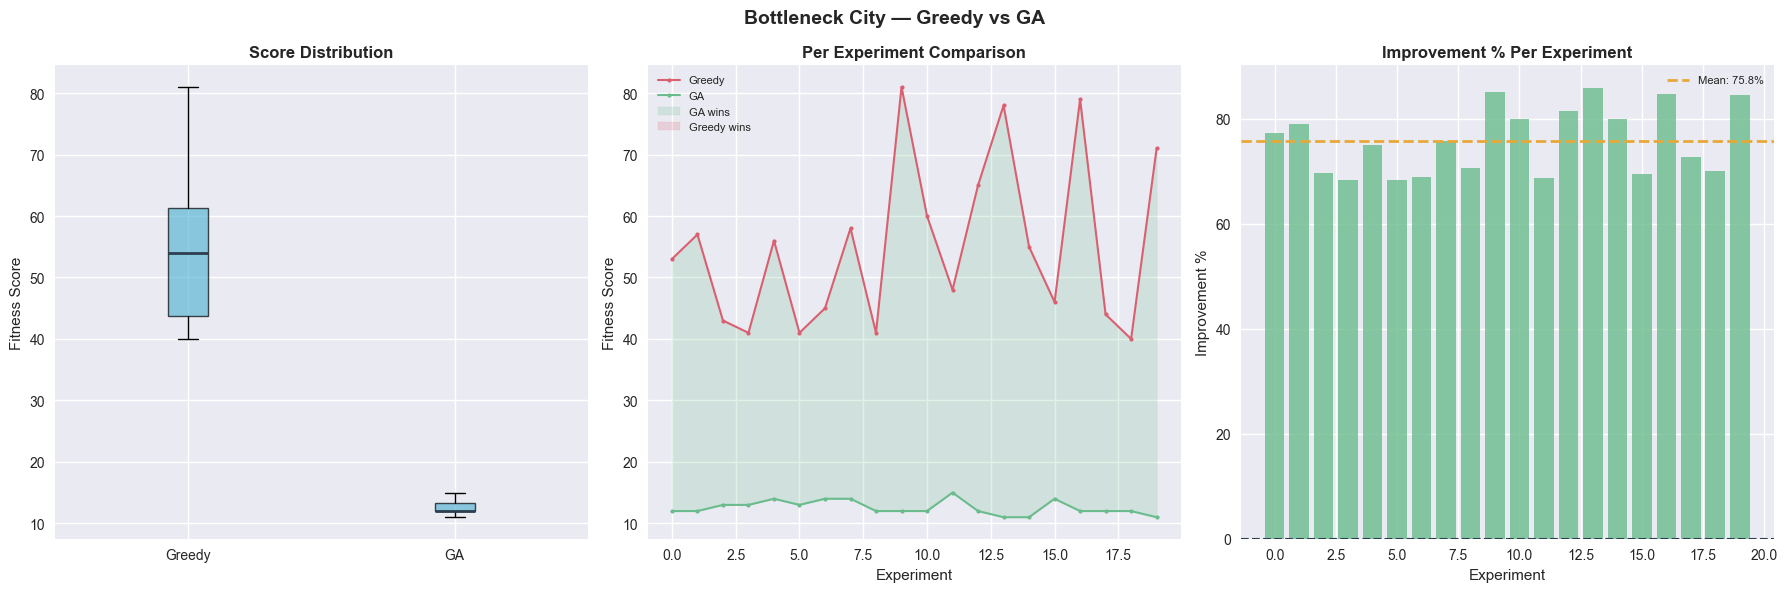


City                     Greedy         GA  Improvement   Win Rate    p-value
----------------------------------------------------------------------
Grid City                 15.65      12.55        13.3%       80%     0.0104
Bottleneck City           55.10      12.55        75.8%      100%     0.0000


In [23]:
results = []
results.append(compare_greedy_vs_ga(solution_grid_greedy,       solution_grid,       "Grid City"))
# results.append(compare_greedy_vs_ga(solution_moderate_greedy,   solution_moderate,   "Moderate City"))
results.append(compare_greedy_vs_ga(solution_bottleneck_greedy, solution_bottleneck, "Bottleneck City"))

# Summary table
print(f"\n{'='*70}")
print(f"{'City':<20} {'Greedy':>10} {'GA':>10} {'Improvement':>12} {'Win Rate':>10} {'p-value':>10}")
print(f"{'-'*70}")
for r in results:
    print(f"{r['city']:<20} {r['greedy_mean']:>10.2f} {r['ga_mean']:>10.2f} "
          f"{r['improvement_pct']:>11.1f}% {r['ga_win_rate']:>9.0%} {r['p_value']:>10.4f}")

## Quick check to ensure agents are comparable...

In [29]:
def verify_seeds(greedy_solutions, ga_solutions):
    """Check that greedy and GA started from the same agent positions"""
    
    assert len(greedy_solutions) == len(ga_solutions), \
        f"Different number of experiments: {len(greedy_solutions)} vs {len(ga_solutions)}"
    
    for i, (greedy, ga) in enumerate(zip(greedy_solutions, ga_solutions)):
        
        # Check same agents
        greedy_starts = {aid: a.start_point for aid, a in greedy.agents.items()}
        ga_starts     = {aid: a.start_point for aid, a in ga.agents.items()}
        
        assert greedy_starts == ga_starts, \
            f"Experiment {i} — agent start points differ:\n  Greedy: {greedy_starts}\n  GA: {ga_starts}"
        
    print(f"✅ All {len(greedy_solutions)} experiments verified — greedy and GA used identical starting conditions")

In [30]:
verify_seeds(solution_grid_greedy, solution_grid)

✅ All 20 experiments verified — greedy and GA used identical starting conditions


In [31]:
verify_seeds(solution_bottleneck_greedy, solution_bottleneck)

AssertionError: Experiment 0 — agent start points differ:
  Greedy: {0: 'S4', 1: 'S2', 2: 'S1', 3: 'S3', 4: 'S2', 5: 'S2', 6: 'S2', 7: 'S2', 8: 'S1', 9: 'S2', 10: 'S1', 11: 'S4', 12: 'S4', 13: 'S4', 14: 'S3', 15: 'S2', 16: 'S4', 17: 'S3', 18: 'S1', 19: 'S1'}
  GA: {0: 'S4', 1: 'S2', 2: 'S1', 3: 'S2', 4: 'S2', 5: 'S1', 6: 'S4', 7: 'S2', 8: 'S3', 9: 'S3', 10: 'S3', 11: 'S3', 12: 'S3', 13: 'S4', 14: 'S4', 15: 'S4', 16: 'S2', 17: 'S1', 18: 'S4', 19: 'S2'}

In [36]:
import numpy as np

def generate_agent_options(options: list, num_agents: int, seed: int) -> list:
    rng = np.random.default_rng(seed)
    return list(rng.choice(options, size=num_agents, replace=True))

In [44]:
from tqdm import tqdm

from multi_agent_ga import KeyManager
from utils.agent import PopulationCreation

rng = np.random.default_rng(123)
algorithm_seeds = rng.integers(0, 10**6, size=n_experiments)

population_creation_seed = []
for seed_idx in tqdm(range(n_experiments)):
    seed = algorithm_seeds[seed_idx]
    key_manager = KeyManager(seed=seed)

    agent_starts = generate_agent_options(city.starts, num_agents, seed)
    agent_speeds = generate_agent_options([1, 2, 3] , num_agents, seed)

    creator = PopulationCreation(
        city=city,
        pop_size=10,
        num_agents=num_agents,
        key_manager=key_manager,
        attributes={'starts': agent_starts, 'walking_speed': agent_speeds}
    )
    population, human_traits = creator.create_initial_population(simulation_params=params)
    population_creation_seed.append(key_manager.key)

100%|██████████| 20/20 [01:00<00:00,  3.04s/it]


In [45]:
from tqdm import tqdm

from multi_agent_ga import KeyManager
from utils.agent import PopulationCreation

rng = np.random.default_rng(123)
algorithm_seeds = rng.integers(0, 10**6, size=n_experiments)

greedy_population_creation_seed = []
for seed_idx in tqdm(range(n_experiments)):
    seed = algorithm_seeds[seed_idx]
    key_manager = KeyManager(seed=seed)

    greedy_agent_starts = generate_agent_options(city.starts, num_agents, seed)
    greedy_agent_speeds = generate_agent_options([1, 2, 3] , num_agents, seed)

    greedy_creator = PopulationCreation(
        city=city,
        pop_size=1,
        num_agents=num_agents,
        key_manager=key_manager,
        attributes={'starts': greedy_agent_starts, 'walking_speed': greedy_agent_speeds}
    )
    greedy_population, greedy_human_traits = greedy_creator.create_initial_population(simulation_params=params)
    greedy_population_creation_seed.append(key_manager.key)

100%|██████████| 20/20 [00:13<00:00,  1.51it/s]
